In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Paths
ROOT_DIR = Path.cwd().parent.parent
fluxes_path = ROOT_DIR / "data" / "processed" / "atmosphere_soil" / "fluxes_dehar_30min.csv"
precip_path = ROOT_DIR / "data" / "processed" / "atmosphere_soil" / "HARTHM_2025_Precipitation_30min_UTC.csv"
meteo_path = ROOT_DIR / "data" / "processed" / "atmosphere_soil" / "meteo_dehar_30min.csv"
soil_moisture_path = ROOT_DIR / "data" / "processed" / "atmosphere_soil" / "soil_moisture_dehar_30min.csv"

# Physiology
sap_flow_path = ROOT_DIR / "data" / "processed" / "physiology" / "sap_flux_density" / "sapflow_dehar_30min.csv"
swp_path = ROOT_DIR / "data" / "processed" / "physiology" / "stemwater_potential" / "swp_dehar_15min.csv"
twd_path = ROOT_DIR / "data" / "processed" / "physiology" / "twd" / "twd_dehar_30min.csv"

In [3]:
# Load data — sep=',' for all files, datetime as index
fluxes = pd.read_csv(fluxes_path, sep=",", parse_dates=["datetime"], index_col="datetime")
meteo = pd.read_csv(meteo_path, sep=",", parse_dates=["datetime"], index_col="datetime")
soil_moisture = pd.read_csv(soil_moisture_path, sep=",", parse_dates=["datetime"], index_col="datetime")

# Precipitation: use the ISO "From" column as datetime
precip = pd.read_csv(precip_path, sep=",", parse_dates=["From"], index_col="From")
precip.index.name = "datetime"
precip = precip[["Precipitation_Sum_mm"]]

# Physiology
sap_flow = pd.read_csv(sap_flow_path, sep=",", parse_dates=["datetime"], index_col="datetime")
swp = pd.read_csv(swp_path, sep=",", parse_dates=["datetime"], index_col="datetime")   # 15-min resolution
twd = pd.read_csv(twd_path, sep=",", parse_dates=["datetime"], index_col="datetime")

# Merge into one DataFrame — outer join preserves all original timestamps
df = pd.concat([fluxes, meteo, soil_moisture, precip, sap_flow, twd, swp], axis=1, join="outer")
df = df.sort_index()

print(df.shape)
df.head()

(28588, 39)


,nee_umol_m2s,nee_f_umol_m2s,nee_f_sd_umol_m2s,gpp_f_umol_m2s,gpp_f_sd_umol_m2s,reco_f_umol_m2s,reco_f_sd_umol_m2s,le_wm2,h_wm2,et_f_mm_h,...,js_h10560,twd_um_h10529,twd_um_h10545,twd_um_h10546,twd_um_h10547,twd_um_h10559,twd_um_h10560,swp_mpa_h10545,swp_mpa_h10546,swp_mpa_h10560
datetime,,,,,,,,,,,,,,,,,,,,,
2024-11-30 23:30:00+00:00,NaN,2.554521,0.539340,-1.225633,0.585500,1.328873,0.057817,-4.0277,3.1045,0.010846,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-01 00:00:00+00:00,NaN,2.549058,0.530672,-1.218217,0.576509,1.330843,0.057648,4.3636,10.6640,0.013623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-01 00:30:00+00:00,NaN,2.540272,0.516790,-1.196787,0.561441,1.343483,0.056527,1.7247,NaN,0.013474,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-01 01:00:00+00:00,NaN,2.533325,0.505867,-1.185427,0.549921,1.347917,0.056128,3.1543,5.6402,0.013480,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-01 01:30:00+00:00,NaN,2.529815,0.500368,-1.190387,0.544768,1.339437,0.056885,4.8135,12.2690,0.013652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import json

def parse_leaf_angle_jsons(cam_id):
    """Parse all JSON files for a given camera ID and return a DataFrame."""
    cam_dir = (
        ROOT_DIR / "data" / "raw" / "proximal_rs" / "anglecam"
        / "leaf-angle-predictions-2025" / f"G5Bullet_{cam_id}"
    )
    records = []
    skipped = 0
    for json_file in sorted(cam_dir.glob(f"G5Bullet_{cam_id}_*_leaf-angle-predictions.json")):
        try:
            with open(json_file) as f:
                data = json.load(f)
        except json.JSONDecodeError:
            print(f"  → skipped corrupt/empty file: {json_file.name}")
            continue
        for frame in data["frames"]:
            if frame["timestamp"] == "missing":
                skipped += 1
                continue
            records.append({
                "datetime": frame["timestamp"],
                f"leaf_angle_cam{cam_id}": frame["predicted_mean_leaf_angle"],
            })
    print(f"cam{cam_id}: {len(records)} frames loaded, {skipped} skipped (missing timestamp)")
    result = pd.DataFrame(records)
    result["datetime"] = pd.to_datetime(result["datetime"], utc=True, errors="coerce")
    n_bad = result["datetime"].isna().sum()
    if n_bad:
        print(f"  → {n_bad} out-of-bounds timestamps dropped (Tesseract artefacts)")
        result = result.dropna(subset=["datetime"])
    result = result.set_index("datetime").sort_index()
    # Average duplicate timestamps (multiple frames recorded at the same second)
    dupes = result.index.duplicated().sum()
    if dupes:
        print(f"  → {dupes} duplicate timestamps averaged")
        result = result.groupby(level=0).mean()
    return result

leaf_angle_60 = parse_leaf_angle_jsons(60)
leaf_angle_61 = parse_leaf_angle_jsons(61)
leaf_angle_62 = parse_leaf_angle_jsons(62)
leaf_angle_63 = parse_leaf_angle_jsons(63)
leaf_angle_64 = parse_leaf_angle_jsons(64)
leaf_angle_65 = parse_leaf_angle_jsons(65)
leaf_angle_66 = parse_leaf_angle_jsons(66)
leaf_angle_67 = parse_leaf_angle_jsons(67)
leaf_angle_68 = parse_leaf_angle_jsons(68)
leaf_angle_69 = parse_leaf_angle_jsons(69)
leaf_angle_70 = parse_leaf_angle_jsons(70)

# Merge into one leaf angle DataFrame (all 11 cameras)
leaf_angle = pd.concat(
    [leaf_angle_60, leaf_angle_61, leaf_angle_62, leaf_angle_63, leaf_angle_64,
     leaf_angle_65, leaf_angle_66, leaf_angle_67, leaf_angle_68, leaf_angle_69, leaf_angle_70],
    axis=1, join="outer"
)
leaf_angle = leaf_angle.sort_index()

# Save to processed
out_path = ROOT_DIR / "data" / "processed" / "proximal_rs" / "anglecam" / "leaf_angle_cam60_70_native.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
leaf_angle.to_csv(out_path)
print(f"Saved {len(leaf_angle)} rows → {out_path.name}")


cam60: 161063 frames loaded, 59 skipped (missing timestamp)
  → 1 out-of-bounds timestamps dropped (Tesseract artefacts)
  → 41 duplicate timestamps averaged
cam61: 139056 frames loaded, 68 skipped (missing timestamp)
  → 45 duplicate timestamps averaged
cam62: 138975 frames loaded, 160 skipped (missing timestamp)
  → 34 duplicate timestamps averaged
cam63: 161695 frames loaded, 123 skipped (missing timestamp)
  → 3 out-of-bounds timestamps dropped (Tesseract artefacts)
  → 44 duplicate timestamps averaged
cam64: 160717 frames loaded, 200 skipped (missing timestamp)
  → 55 duplicate timestamps averaged
cam65: 160890 frames loaded, 67 skipped (missing timestamp)
  → 2 out-of-bounds timestamps dropped (Tesseract artefacts)
  → 39 duplicate timestamps averaged
cam66: 156839 frames loaded, 272 skipped (missing timestamp)
  → 60 duplicate timestamps averaged
cam67: 156770 frames loaded, 309 skipped (missing timestamp)
  → 1 out-of-bounds timestamps dropped (Tesseract artefacts)
  → 48 dupli

In [14]:
# Append to main DataFrame (outer join — keeps native ~2-min resolution rows)
df = pd.concat([df, leaf_angle], axis=1, join="outer")
df = df.sort_index()

print(df.shape)
#df[["leaf_angle_cam65", "leaf_angle_cam66", "leaf_angle_cam67"]].dropna(how="all").head()

(1059976, 50)


Leaf angle filter: 121622 frames masked (12.7%) — wind > None m/s  |  rain > 0.0001 mm + 12.0 h lockout
HE1: 2025-06-16 → 2025-07-05  (20 days, mean Tmax 29.5 °C)
HE2: 2025-08-06 → 2025-08-19  (14 days, mean Tmax 31.1 °C)
Saved → /mnt/data/lk1167/projects/dehar-spac/figures/compound_event_5panel.png


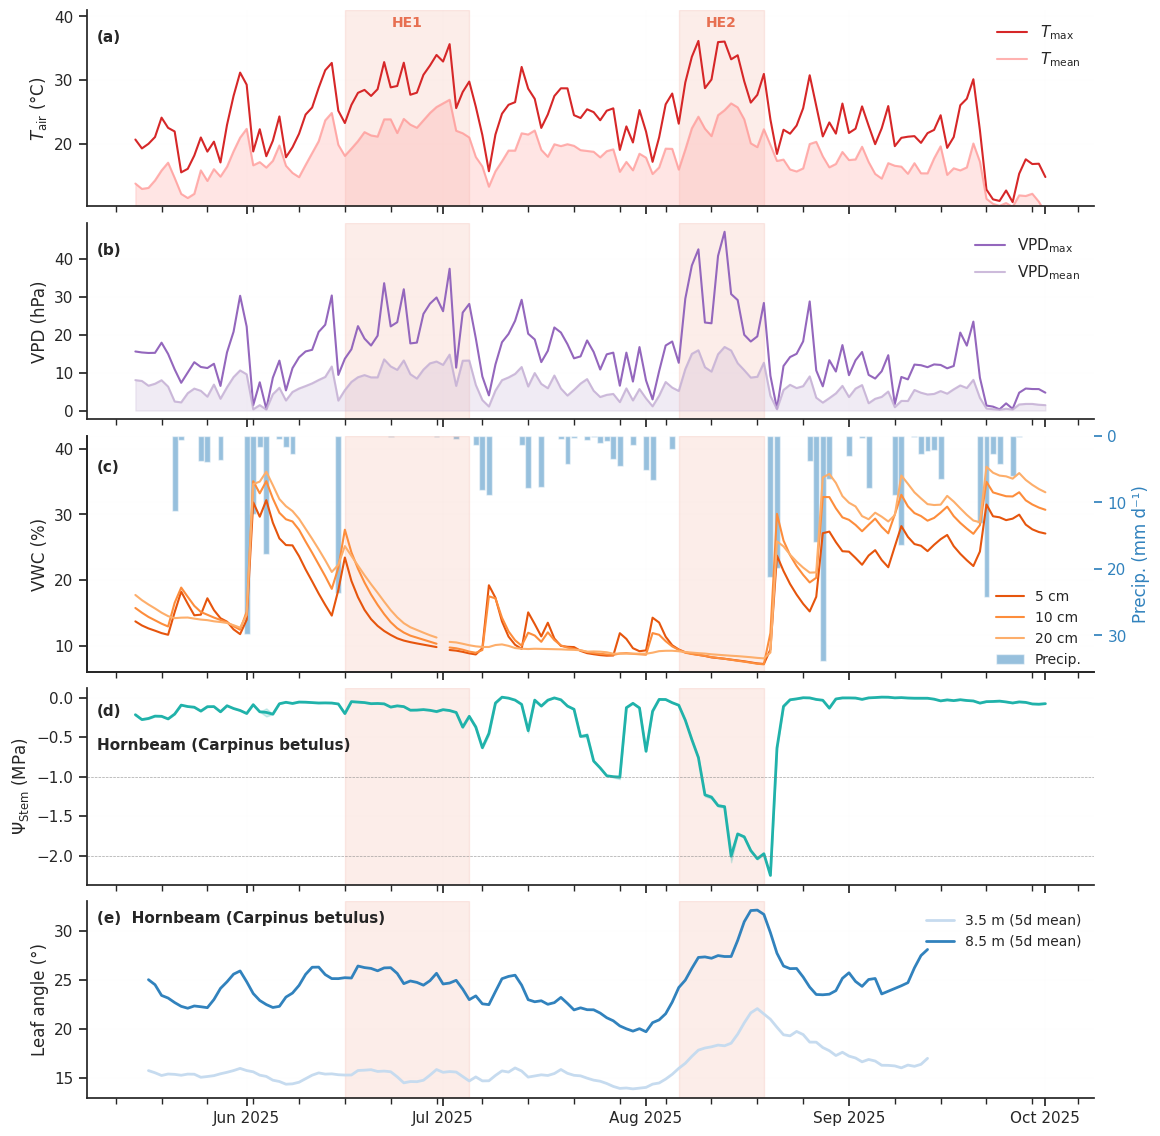

In [291]:
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

# ── User settings ────────────────────────────────────────────────────────────
# Leaf angle daily aggregation window.
# Options: "day" | "night" | "predawn" | tuple of UTC hours e.g. (6, 18)
LEAF_ANGLE_WINDOW = (7,19)   # <-- change here "(0,24)" 
ROLLING_DAYS      = 5      # rolling-mean window in days (set to 1 to disable)

# VWC profile: "a", "b", or "c"
VWC_PROFILE = "a"

# ── Leaf angle quality filter ─────────────────────────────────────────────────
# Wind: mask frames where ustar exceeds threshold (set to None to disable)
WIND_USTAR_THRESHOLD = None   # m/s
# Rain: mask frames during precipitation and N hours after the last wet step
PRECIP_THRESHOLD_MM  = 0.0001   # mm per 30-min step — event trigger
PRECIP_LOCKOUT_H     = 12.0   # hours to keep masking after last wet step

# Figure output path (set to None to skip saving)
FIG_OUT = ROOT_DIR / "figures" / "compound_event_5panel.png"
# ─────────────────────────────────────────────────────────────────────────────

# ── Color palette from tab20c — no green, no red-green clash ──────────────────
_tab20 = plt.cm.tab20.colors
_tab20c = plt.cm.tab20c.colors

# (a) Temperature: red group (tab20c group 3)
C_TMAX    = _tab20[6]   # dark red   — Tmax
C_TMEAN   = _tab20[7]   # light red  — Tmean

# (b) VPD: purple group (tab20c group 4)
C_VPDMAX  = _tab20[8]   # dark purple  — VPDmax
C_VPDMEAN = _tab20[9]   # light purple — VPDmean

# (c) VWC: orange group (tab20c group 1, dark→light by depth)
C_VWC5    = _tab20c[4]    # dark orange  — 5 cm
C_VWC10   = _tab20c[5]    # medium       — 10 cm
C_VWC20   = _tab20c[6]    # light orange — 20 cm
C_PRECIP  = _tab20c[0]    # blue (group 0, darkest) — precipitation

# (d) SWP: brown (distinct from all groups above)
C_SWP     = "lightseagreen"   # teal-ish, stands out from all tab20/tab20c colors

# (e) Leaf angle: blue group (tab20c group 0, higher = darker)
C_LA65    = _tab20c[3]    # lightest blue — 3.5 m
C_LA66    = _tab20c[1]    # medium blue   — 6.5 m
C_LA67    = _tab20c[0]    # darkest blue  — 8.5 m

sns.set_theme(style="ticks", font_scale=1.0)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.01,
    "grid.linestyle": "--",
})

# ── Helper: find sunrise per day from radiation signal ───────────────────────
def get_sunrise_utc(rg_series):
    """Return a Series indexed by date with first UTC hour of positive radiation."""
    df_rg = rg_series.copy().to_frame("rg")
    df_rg["date"] = df_rg.index.normalize()
    df_rg = df_rg[df_rg["rg"] > 5]
    return df_rg.groupby("date").apply(lambda g: g.index.min().hour + g.index.min().minute / 60)

# ── Prepare 30-min base data ──────────────────────────────────────────────────
def ensure_utc(series_or_df):
    idx = series_or_df.index
    if idx.tz is None:
        return series_or_df.tz_localize("UTC")
    return series_or_df.tz_convert("UTC")

meteo_u  = ensure_utc(meteo)
sm_u     = ensure_utc(soil_moisture)
precip_u = ensure_utc(precip)
swp_u    = ensure_utc(swp)
leaf_u   = ensure_utc(leaf_angle)

# Restrict to growing season where most data overlap
t_start = "2025-05-15"
t_end   = "2025-10-01"
meteo_u  = meteo_u.loc[t_start:t_end]
sm_u     = sm_u.loc[t_start:t_end]
precip_u = precip_u.loc[t_start:t_end]
swp_u    = swp_u.loc[t_start:t_end]
leaf_u   = leaf_u.loc[t_start:t_end]

# ── Panel 1 & 2: daily Tair and VPD ──────────────────────────────────────────
tair_daily_mean = meteo_u["tair_c"].resample("1D").mean()
tair_daily_max  = meteo_u["tair_c"].resample("1D").max()
vpd_daily_mean  = meteo_u["vpd_hpa"].resample("1D").mean()
vpd_daily_max   = meteo_u["vpd_hpa"].resample("1D").max()

# ── Panel 3: VWC profile + daily precipitation ───────────────────────────────
vwc_5   = sm_u[f"vwc_pct_{VWC_PROFILE}_5cm"].resample("1D").mean()
vwc_10  = sm_u[f"vwc_pct_{VWC_PROFILE}_10cm"].resample("1D").mean()
vwc_20  = sm_u[f"vwc_pct_{VWC_PROFILE}_20cm"].resample("1D").mean()
precip_daily = precip_u["Precipitation_Sum_mm"].resample("1D").sum()

# ── Panel 4: SWP predawn h10546 ──────────────────────────────────────────────
sunrise_h = get_sunrise_utc(meteo_u["rg_wm2"])
swp_col = swp_u["swp_mpa_h10546"].dropna()
predawn_vals = {}
predawn_stds = {}
predawn_counts = {}
for date, sr_h in sunrise_h.items():
    base      = pd.Timestamp(date).tz_localize("UTC") if pd.Timestamp(date).tzinfo is None else pd.Timestamp(date).tz_convert("UTC")
    base      = base.normalize()
    win_end   = base + pd.Timedelta(hours=float(sr_h))
    win_start = win_end - pd.Timedelta(hours=2)
    window    = swp_col.loc[win_start:win_end]
    if len(window) > 0:
        predawn_vals[date] = window.mean()
        predawn_stds[date] = window.std()
        predawn_counts[date] = len(window)

swp_predawn = pd.Series(predawn_vals, name="swp_predawn")
swp_predawn.index = pd.DatetimeIndex(swp_predawn.index, tz="UTC")
swp_predawn_std = pd.Series(predawn_stds)
swp_predawn_std.index = pd.DatetimeIndex(swp_predawn_std.index, tz="UTC")
swp_predawn_n = pd.Series(predawn_counts)
swp_predawn_n.index = pd.DatetimeIndex(swp_predawn_n.index, tz="UTC")
swp_predawn_ci = 1.96 * swp_predawn_std / np.sqrt(swp_predawn_n)

# ── Leaf angle quality filter ─────────────────────────────────────────────────
def build_leaf_quality_mask(leaf_idx, meteo_df, precip_df,
                            ustar_thr=None, precip_thr=0.1, lockout_h=2.0):
    """Return a boolean Series (True = keep) aligned to leaf_idx.

    Parameters
    ----------
    ustar_thr  : float | None  — mask frames above this ustar (m/s); None = off
    precip_thr : float         — precipitation trigger (mm per 30-min step)
    lockout_h  : float         — hours to continue masking after last wet step
    """
    mask = pd.Series(True, index=leaf_idx)

    # Wind filter — use ustar as friction-velocity / turbulence proxy
    if ustar_thr is not None and "ustar_ms" in meteo_df.columns:
        ustar = meteo_df["ustar_ms"].reindex(
            leaf_idx, method="nearest", tolerance=pd.Timedelta("30min")
        )
        mask &= ustar.fillna(0) <= ustar_thr

    # Rain filter — mask during rain + lockout window afterwards
    if "Precipitation_Sum_mm" in precip_df.columns:
        p = precip_df["Precipitation_Sum_mm"].reindex(
            leaf_idx, method="nearest", tolerance=pd.Timedelta("30min")
        ).fillna(0)
        wet = (p >= precip_thr).astype(float)
        # Rolling max over lockout window (frames are ~2 min apart)
        n_steps = max(1, int(np.ceil(lockout_h * 60 / 2)))
        wet_padded = wet.rolling(n_steps, min_periods=1).max()
        mask &= wet_padded == 0

    return mask

leaf_mask = build_leaf_quality_mask(
    leaf_u.index, meteo_u, precip_u,
    ustar_thr  = WIND_USTAR_THRESHOLD,
    precip_thr = PRECIP_THRESHOLD_MM,
    lockout_h  = PRECIP_LOCKOUT_H,
)
leaf_u_filtered = leaf_u[leaf_mask]
n_removed = (~leaf_mask).sum()
print(f"Leaf angle filter: {n_removed} frames masked "
      f"({100 * n_removed / len(leaf_mask):.1f}%) — "
      f"wind > {WIND_USTAR_THRESHOLD} m/s  |  "
      f"rain > {PRECIP_THRESHOLD_MM} mm + {PRECIP_LOCKOUT_H} h lockout")

# ── Panel 5: leaf angle daily aggregation ────────────────────────────────────
def aggregate_leaf_angle(leaf_df, window):
    """Return daily mean of leaf angles for the chosen window."""
    if window == "day":
        mask = (leaf_df.index.hour >= 6) & (leaf_df.index.hour < 20)
    elif window == "night":
        mask = (leaf_df.index.hour < 6) | (leaf_df.index.hour >= 20)
    elif window == "predawn":
        mask = (leaf_df.index.hour >= 3) & (leaf_df.index.hour < 5)
    elif isinstance(window, tuple):
        h0, h1 = window
        mask = (leaf_df.index.hour >= h0) & (leaf_df.index.hour < h1)
    else:
        mask = slice(None)
    return leaf_df[mask].resample("1D").mean()

la_daily = aggregate_leaf_angle(leaf_u_filtered, LEAF_ANGLE_WINDOW)
la65_d = la_daily["leaf_angle_cam65"].rolling(ROLLING_DAYS, center=True).mean()
la66_d = la_daily["leaf_angle_cam66"].rolling(ROLLING_DAYS, center=True).mean()
la67_d = la_daily["leaf_angle_cam67"].rolling(ROLLING_DAYS, center=True).mean()
la65_std = la_daily["leaf_angle_cam65"].rolling(ROLLING_DAYS, center=True).std()
la67_std = la_daily["leaf_angle_cam67"].rolling(ROLLING_DAYS, center=True).std()
la65_ci = 1.96 * la65_std / np.sqrt(ROLLING_DAYS)
la67_ci = 1.96 * la67_std / np.sqrt(ROLLING_DAYS)

# ── Detect dry + hot spells (≥10 consecutive dry days, Tmax ≥ 25 °C mean) ───
DRY_RUN_MIN_DAYS = 10
TMAX_HOT_THR     = 25.0   # °C — mean Tmax over the spell must exceed this

dry_day = (precip_daily <= 0.5)   # essentially no rain
dry_day = dry_day.astype(int)
# Label consecutive dry runs
_groups = (dry_day != dry_day.shift()).cumsum()
_runs = dry_day.groupby(_groups).transform("sum")
dry_spells = dry_day.copy()
dry_spells[:] = 0
dry_spells[_runs >= DRY_RUN_MIN_DAYS] = 1

# Extract start/end of each qualifying dry run
_spell_groups = (dry_spells != dry_spells.shift()).cumsum()
hot_dry_events = []
for gid, grp in dry_spells.groupby(_spell_groups):
    if grp.iloc[0] == 0:
        continue
    spell_start, spell_end = grp.index[0], grp.index[-1]
    mean_tmax = tair_daily_max.loc[spell_start:spell_end].mean()
    if mean_tmax >= TMAX_HOT_THR:
        hot_dry_events.append((spell_start, spell_end))

# Keep only the two longest (or first two)
hot_dry_events.sort(key=lambda x: (x[1] - x[0]), reverse=True)
hot_dry_events = hot_dry_events[:2]
hot_dry_events.sort(key=lambda x: x[0])  # chronological order

for i, (s, e) in enumerate(hot_dry_events):
    print(f"HE{i+1}: {s.strftime('%Y-%m-%d')} → {e.strftime('%Y-%m-%d')}  "
          f"({(e-s).days+1} days, "
          f"mean Tmax {tair_daily_max.loc[s:e].mean():.1f} °C)")

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    5, 1, figsize=(13, 16),
    sharex=True,
    gridspec_kw={"hspace": 0.08, "height_ratios": [1, 1, 1.2, 1, 1]}
)

def label_panel(ax, letter, x=0.01, y=0.90):
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

# ── Shade hot-dry events across all panels ────────────────────────────────────
HE_COLOR = "#E76F51"   # warm terracotta
for ax in axes:
    for j, (s, e) in enumerate(hot_dry_events):
        ax.axvspan(s, e, color=HE_COLOR, alpha=0.12, zorder=0)
# Label on the top panel only
for j, (s, e) in enumerate(hot_dry_events):
    mid = s + (e - s) / 2
    axes[0].text(mid, 0.97, f"HE{j+1}", transform=axes[0].get_xaxis_transform(),
                 ha="center", va="top", fontsize=10, fontweight="bold", color=HE_COLOR)

# ── (a) Temperature ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(tair_daily_max.index,  tair_daily_max.values,  color=C_TMAX,  lw=1.5, label=r"$T_\mathrm{max}$")
ax.plot(tair_daily_mean.index, tair_daily_mean.values, color=C_TMEAN, lw=1.5, label=r"$T_\mathrm{mean}$", alpha=0.75)
ax.fill_between(tair_daily_mean.index, tair_daily_mean.values, alpha=0.25, color=C_TMEAN)
ax.set_ylabel(r"$T_\mathrm{air}$ (°C)")
ax.legend(loc="upper right", frameon=False, fontsize=11)
ax.set_ylim(np.percentile(tair_daily_mean.values, 1) - 0, np.percentile(tair_daily_max.values, 99) + 5)
label_panel(ax, "(a)")

# ── (b) VPD ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.fill_between(vpd_daily_mean.index, vpd_daily_mean.values, alpha=0.25, color=C_VPDMEAN)
ax.plot(vpd_daily_max.index,  vpd_daily_max.values,  color=C_VPDMAX,  lw=1.5, label=r"VPD$_\mathrm{max}$")
ax.plot(vpd_daily_mean.index, vpd_daily_mean.values, color=C_VPDMEAN, lw=1.5, label=r"VPD$_\mathrm{mean}$", alpha=0.85)
ax.set_ylabel("VPD (hPa)")
ax.legend(loc="upper right", frameon=False, fontsize=11)
label_panel(ax, "(b)")

# ── (c) VWC + precipitation ───────────────────────────────────────────────────
ax  = axes[2]
ax2 = ax.twinx()
ax2.bar(precip_daily.index, precip_daily.values, color=C_PRECIP,
        alpha=0.5, width=0.9, zorder=1, label="Precip.")
ax2.invert_yaxis()
ax2.set_ylabel("Precip. (mm d⁻¹)", color=C_PRECIP)
ax2.tick_params(axis="y", colors=C_PRECIP)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(C_PRECIP)
ax2.spines["top"].set_visible(False)
ax.plot(vwc_5.index,  vwc_5.values,  color=C_VWC5,  lw=1.5, label="5 cm",  zorder=3)
ax.plot(vwc_10.index, vwc_10.values, color=C_VWC10, lw=1.5, label="10 cm", zorder=3)
ax.plot(vwc_20.index, vwc_20.values, color=C_VWC20, lw=1.5, label="20 cm", zorder=3)
ax.set_ylabel("VWC (%)")
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
lines_a, labels_a = ax.get_legend_handles_labels()
lines_b, labels_b = ax2.get_legend_handles_labels()
ax.legend(lines_a + lines_b, labels_a + labels_b, bbox_to_anchor=(1.0, 0.4), loc="upper right", frameon=False, fontsize=10)
ax.set_ylim(6, 42)
label_panel(ax, "(c)")

# ── (d) SWP predawn h10546 ───────────────────────────────────────────────────
ax = axes[3]
ax.fill_between(swp_predawn.index,
                (swp_predawn - swp_predawn_ci).values,
                (swp_predawn + swp_predawn_ci).values,
                color=C_SWP, alpha=0.2)
ax.plot(swp_predawn.index, swp_predawn.values, color=C_SWP, lw=2, label="h10546")
ax.axhline(-1.0, color="gray", lw=0.5, ls="--", alpha=0.7)
ax.axhline(-2.0, color="gray", lw=0.5, ls="--", alpha=0.7)
ax.set_ylabel(r"$\Psi_\mathrm{Stem}$ (MPa)")
#ax.legend(loc="lower left", frameon=False, fontsize=9)
label_panel(ax, "(d)", x=0.01, y=0.92)
label_panel(ax, "Hornbeam (Carpinus betulus)", x=0.01, y=0.75)

# ── (e) Leaf angle ────────────────────────────────────────────────────────────
window_label = {
    "day": "day (06–20 UTC)", "night": "night (20–06 UTC)",
    "predawn": "predawn (03–05 UTC)"
}.get(LEAF_ANGLE_WINDOW, f"{LEAF_ANGLE_WINDOW[0]}–{LEAF_ANGLE_WINDOW[1]} UTC"
      if isinstance(LEAF_ANGLE_WINDOW, tuple) else LEAF_ANGLE_WINDOW)

ax = axes[4]
#ax.fill_between(la65_d.index, (la65_d - la65_ci).values, (la65_d + la65_ci).values, color=C_LA65, alpha=0.2)
#ax.fill_between(la67_d.index, (la67_d - la67_ci).values, (la67_d + la67_ci).values, color=C_LA67, alpha=0.2)
ax.plot(la65_d.index, la65_d.values, color=C_LA65, lw=2, label=f"3.5 m ({ROLLING_DAYS}d mean)")
#ax.plot(la66_d.index, la66_d.values, color=C_LA66, lw=2, label=f"cam66 — 6.5 m ({ROLLING_DAYS}d)")
ax.plot(la67_d.index, la67_d.values, color=C_LA67, lw=2, label=f"8.5 m ({ROLLING_DAYS}d mean)")
ax.set_ylabel("Leaf angle (°)")
ax.legend(loc="upper right", frameon=False, fontsize=10)
label_panel(ax, f"(e)  Hornbeam (Carpinus betulus)", x=0.01, y=0.95)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
fig.autofmt_xdate(rotation=0, ha="center")

sns.despine(fig=fig, right=True, top=True)
axes[2].spines["left"].set_visible(True)

plt.tight_layout()

if FIG_OUT:
    FIG_OUT.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_OUT, dpi=200, bbox_inches="tight")
    print(f"Saved → {FIG_OUT}")

plt.show()

Quality filter: 123012 frames masked (12.2%)
Saved → /mnt/data/lk1167/projects/dehar-spac/figures/leaf_angle_multi_tree.png


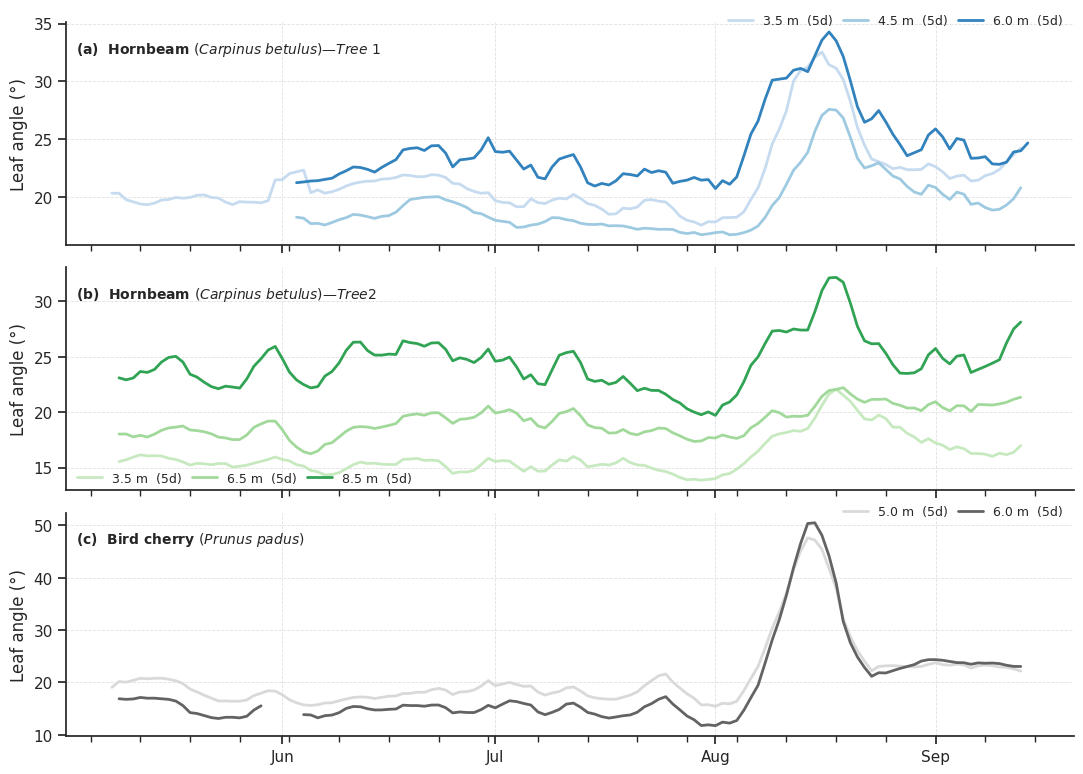

In [190]:
from collections import OrderedDict
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

# ── User settings ─────────────────────────────────────────────────────────────
TREE_LEAF_WINDOW    = (7, 19)
TREE_ROLLING_DAYS   = 5
TREE_USTAR_THR      = None
TREE_PRECIP_THR     = 0.0001
TREE_PRECIP_LOCKOUT = 12.0
TREE_T_START = "2025-05-06"
TREE_T_END   = "2025-10-01"
TREE_FIG_OUT = ROOT_DIR / "figures" / "leaf_angle_multi_tree.png"
# ─────────────────────────────────────────────────────────────────────────────

CAM_META = {
    60: ("h10559", 3.5),
    61: ("h10559", 4.5),
    62: ("h10559", 6.0),
    #63: ("h10559", 7.0),
    #64: ("h10546", 4.5),
    65: ("h10546", 3.5),
    66: ("h10546", 6.5),
    67: ("h10546", 8.5),
    68: ("h11033", 5.0),
    69: ("h11033", 6.0),
    #70: ("h10560", 6.0),
}

TREE_NAMES = {
    "h10559": r"Hornbeam $(\mathit{Carpinus\ betulus}) — Tree\ 1 $",
    "h10546": r"Hornbeam $(\mathit{Carpinus\ betulus}) — Tree 2 $",
    "h11033": r"Bird cherry $(\mathit{Prunus\ padus})$",
    "h10560": "Unknown",
}

# Per-panel color gradient from tab20c: each panel uses a different hue group
# tab20c groups (4 shades each): 0=blue, 1=orange, 2=green, 3=red, 4=purple
# Within each group: index 0 = darkest, index 3 = lightest → higher = darker
_tab20c = _cm.get_cmap("tab20c")

def panel_colors(panel_idx, n_colors):
    """Return n_colors from tab20c group (higher = darker).
    Groups used: 0=blue, 2=green, 4=purple (skipping orange and red).
    """
    _group_map = {0: 0, 1: 2, 2: 4}   # panel → tab20c group index
    group_start = _group_map.get(panel_idx, panel_idx) * 4
    indices = np.round(np.linspace(3, 0, n_colors)).astype(int)
    return [_tab20c.colors[group_start + j] for j in indices]

# ── Prepare data ──────────────────────────────────────────────────────────────
leaf_t   = ensure_utc(leaf_angle).loc[TREE_T_START:TREE_T_END]
meteo_t  = ensure_utc(meteo).loc[TREE_T_START:TREE_T_END]
precip_t = ensure_utc(precip).loc[TREE_T_START:TREE_T_END]

tree_mask = build_leaf_quality_mask(
    leaf_t.index, meteo_t, precip_t,
    ustar_thr  = TREE_USTAR_THR,
    precip_thr = TREE_PRECIP_THR,
    lockout_h  = TREE_PRECIP_LOCKOUT,
)
leaf_tf = leaf_t[tree_mask]
n_masked = (~tree_mask).sum()
print(f"Quality filter: {n_masked} frames masked "
      f"({100 * n_masked / len(tree_mask):.1f}%)")

# ── Window aggregation ────────────────────────────────────────────────────────
def agg_tree_window(leaf_df, window):
    if window == "day":
        m = (leaf_df.index.hour >= 6) & (leaf_df.index.hour < 20)
    elif window == "night":
        m = (leaf_df.index.hour < 6) | (leaf_df.index.hour >= 20)
    elif window == "predawn":
        m = (leaf_df.index.hour >= 3) & (leaf_df.index.hour < 5)
    elif isinstance(window, tuple):
        h0, h1 = window
        m = (leaf_df.index.hour >= h0) & (leaf_df.index.hour < h1)
    else:
        m = slice(None)
    daily_mean = leaf_df[m].resample("1D").mean()
    daily_std  = leaf_df[m].resample("1D").std()
    return daily_mean, daily_std

la_daily_tree, la_daily_tree_std = agg_tree_window(leaf_tf, TREE_LEAF_WINDOW)

# ── Organize by tree ──────────────────────────────────────────────────────────
_active_trees = {tid for tid, _ in CAM_META.values()}
TREES = [t for t in ["h10559", "h10546", "h11033", "h10560"] if t in _active_trees]

tree_data = OrderedDict()
for tree in TREES:
    tree_data[tree] = {}
    for cam_id, (tree_id, height) in CAM_META.items():
        if tree_id != tree:
            continue
        col = f"leaf_angle_cam{cam_id}"
        if col not in la_daily_tree.columns:
            continue
        raw = la_daily_tree[col]
        first_valid = raw.first_valid_index()
        rolled = raw.rolling(TREE_ROLLING_DAYS, center=True).mean()
        if first_valid is not None:
            rolled = rolled.loc[first_valid:]
        tree_data[tree][height] = rolled

# ── Figure ────────────────────────────────────────────────────────────────────
window_label = {
    "day":     "day (06–20 UTC)",
    "night":   "night (20–06 UTC)",
    "predawn": "predawn (03–05 UTC)",
}.get(
    TREE_LEAF_WINDOW,
    f"{TREE_LEAF_WINDOW[0]}–{TREE_LEAF_WINDOW[1]} UTC"
    if isinstance(TREE_LEAF_WINDOW, tuple) else str(TREE_LEAF_WINDOW)
)

n_trees = len(TREES)
fig, axes = plt.subplots(
    n_trees, 1, figsize=(13, 3.5 * n_trees),
    sharex=True,
    gridspec_kw={"hspace": 0.10},
)
if n_trees == 1:
    axes = [axes]

xfmt = mdates.DateFormatter("%b")
xloc = mdates.MonthLocator()

for i, tree in enumerate(TREES):
    ax = axes[i]
    heights_sorted = sorted(tree_data[tree].keys())
    colors = panel_colors(i, len(heights_sorted))
    for k, height in enumerate(heights_sorted):
        series = tree_data[tree][height]
        ax.plot(series.index, series.values, color=colors[k], lw=2,
                label=f"{height} m  ({TREE_ROLLING_DAYS}d)")
    ax.set_ylabel("Leaf angle (°)")
    letter = chr(ord("a") + i)
    name = TREE_NAMES.get(tree, tree)
    ax.text(0.01, 0.92, f"({letter})  {name}",
            transform=ax.transAxes, fontsize=10, fontweight="bold", va="top")
    leg_loc    = "lower left" if i == 1 else "upper right"
    leg_anchor = (0.0, -0.0250) if i == 1 else (1.0, 1.085)
    ax.legend(loc=leg_loc, bbox_to_anchor=leg_anchor, frameon=False, fontsize=9, ncol=len(heights_sorted), columnspacing=0.8)

axes[-1].xaxis.set_major_locator(xloc)
axes[-1].xaxis.set_major_formatter(xfmt)
axes[-1].xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
fig.autofmt_xdate(rotation=0, ha="center")

# fig.suptitle(
#     f"Leaf angle per tree — DE-Har 2025  ({TREE_ROLLING_DAYS}d rolling mean, {window_label})",
#     fontsize=12, fontweight="bold", y=1.005,
# )
sns.despine(fig=fig, right=True, top=True)
plt.tight_layout()

if TREE_FIG_OUT:
    TREE_FIG_OUT.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(TREE_FIG_OUT, dpi=200, bbox_inches="tight")
    print(f"Saved → {TREE_FIG_OUT}")

plt.show()


Saved → /mnt/data/lk1167/projects/dehar-spac/figures/correlations_physiology_vs_leaf_angle.png


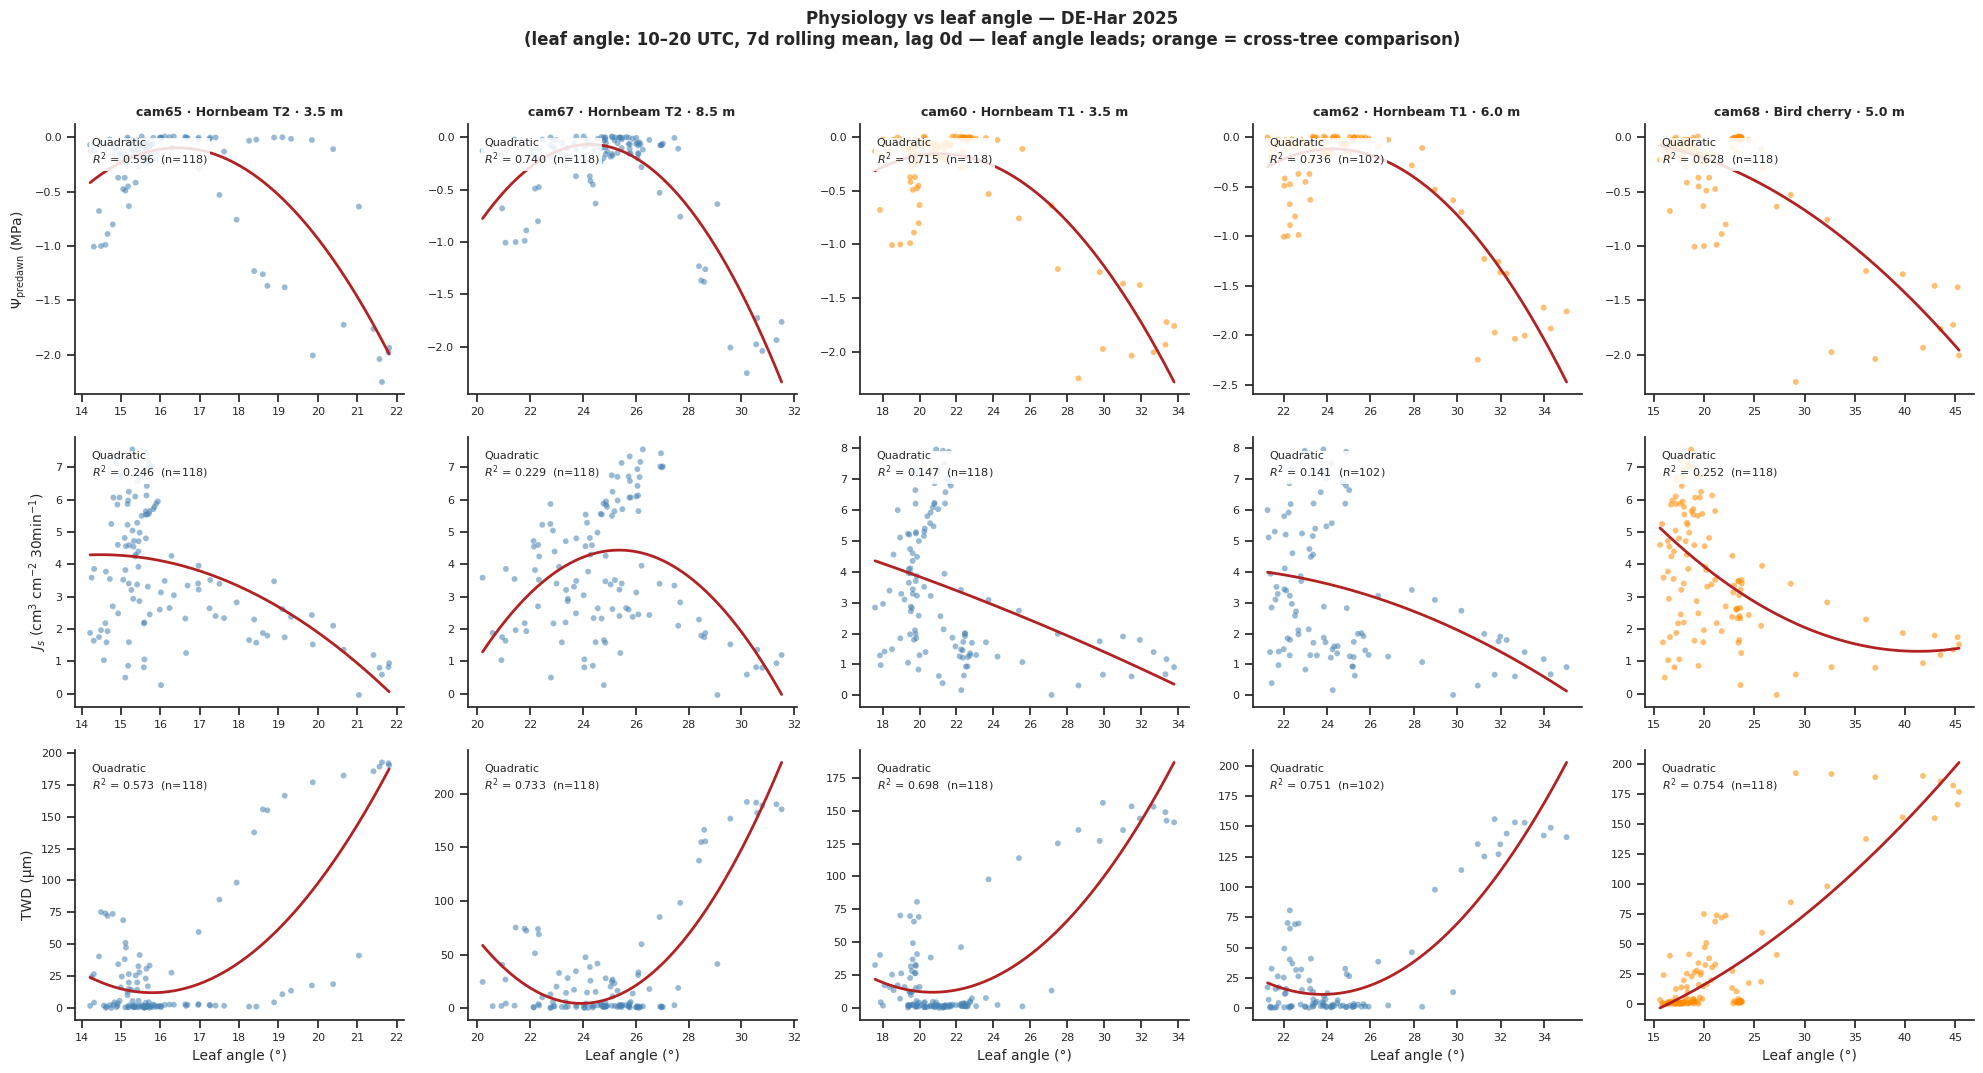

In [277]:
from scipy.optimize import curve_fit

# ── Settings ──────────────────────────────────────────────────────────────────
CORR_ROLLING = 7
CORR_WINDOW  = (10, 20)
CORR_LAG     = 0          # days — positive = leaf angle leads physiology
CORR_FIG_OUT = ROOT_DIR / "figures" / "correlations_physiology_vs_leaf_angle.png"

# ── Regression models ─────────────────────────────────────────────────────────
def _lin(x, a, b):      return a * x + b
def _quad(x, a, b, c):  return a * x**2 + b * x + c
def _exp(x, a, b, c):   return a * np.exp(np.clip(b * x, -50, 50)) + c
def _log(x, a, b):      return a * np.log(np.clip(x, 1e-10, None)) + b

def best_regression(x, y):
    """Try linear, quadratic, exponential, logarithmic; return best by R²."""
    ss_tot = np.sum((y - y.mean()) ** 2)
    if ss_tot == 0 or len(x) < 10:
        return None
    best_r2, result = -np.inf, None
    xf = np.linspace(x.min(), x.max(), 200)

    # Linear
    try:
        popt, _ = curve_fit(_lin, x, y, maxfev=5000)
        r2 = 1 - np.sum((y - _lin(x, *popt)) ** 2) / ss_tot
        if r2 > best_r2:
            best_r2, result = r2, ("Linear", r2, xf, _lin(xf, *popt))
    except Exception:
        pass

    # Quadratic
    try:
        popt, _ = curve_fit(_quad, x, y, maxfev=5000)
        r2 = 1 - np.sum((y - _quad(x, *popt)) ** 2) / ss_tot
        if r2 > best_r2:
            best_r2, result = r2, ("Quadratic", r2, xf, _quad(xf, *popt))
    except Exception:
        pass

    # Exponential — try multiple initial conditions
    for b0 in [0.01, -0.01, 0.1, -0.1]:
        try:
            popt, _ = curve_fit(_exp, x, y, p0=[1.0, b0, y.mean()], maxfev=10000)
            r2 = 1 - np.sum((y - _exp(x, *popt)) ** 2) / ss_tot
            if r2 > best_r2:
                best_r2, result = r2, ("Exponential", r2, xf, _exp(xf, *popt))
        except Exception:
            pass

    # Logarithmic — only valid if x > 0
    if np.all(x > 0):
        try:
            popt, _ = curve_fit(_log, x, y, p0=[1.0, y.mean()], maxfev=5000)
            r2 = 1 - np.sum((y - _log(x, *popt)) ** 2) / ss_tot
            if r2 > best_r2:
                result = ("Logarithmic", r2, xf, _log(xf, *popt))
        except Exception:
            pass

    return result

# ── Prepare leaf-angle daily rolling means (all cameras) ─────────────────────
_h0, _h1 = CORR_WINDOW
_la_filt = leaf_u_filtered  # already quality-filtered & clipped to t_start:t_end
_la_win  = _la_filt[(_la_filt.index.hour >= _h0) & (_la_filt.index.hour < _h1)]
_la_day  = _la_win.resample("1D").mean()
_la_roll = _la_day.rolling(CORR_ROLLING, center=True).mean()

# Apply lag: shift leaf angle back so day T leaf angle pairs with day T+lag physiology
_la_roll_lagged = _la_roll.shift(-CORR_LAG)

# ── Prepare physiology daily series ───────────────────────────────────────────
# Sap flow — daytime daily mean
_sf = ensure_utc(sap_flow).loc[t_start:t_end]
_sf_day = _sf[(_sf.index.hour >= _h0) & (_sf.index.hour < _h1)].resample("1D").mean()

# TWD — daily mean
_twd = ensure_utc(twd).loc[t_start:t_end]
_twd_day = _twd.resample("1D").mean()

# SWP predawn — already computed as `swp_predawn` (h10546)

# ── Grid definition ──────────────────────────────────────────────────────────
# Columns: (cam_id, cam_tree, height_m)
GRID_CAMS = [
    (65, "h10546", 3.5),
    (67, "h10546", 8.5),
    (60, "h10559", 3.5),
    (62, "h10559", 6.0),
    (68, "h11033", 5.0),
]
TREE_SHORT = {"h10546": "Hornbeam T2", "h10559": "Hornbeam T1", "h11033": "Bird cherry"}

def _get_phys(row_idx, cam_tree):
    """Return (Series, tree_id_used) for the given row and camera tree."""
    if row_idx == 0:                               # SWP predawn (h10546 only)
        return swp_predawn, "h10546"
    elif row_idx == 1:                             # Sap flow (matching tree)
        c = f"js_{cam_tree}"
        if c in _sf_day.columns:
            return _sf_day[c], cam_tree
        return _sf_day["js_h10546"], "h10546"      # fallback
    else:                                          # TWD (matching tree)
        c = f"twd_um_{cam_tree}"
        if c in _twd_day.columns:
            return _twd_day[c], cam_tree
        return _twd_day["twd_um_h10546"], "h10546"

ROW_YLABELS = [
    r"$\Psi_\mathrm{predawn}$ (MPa)",
    r"$J_s$ (cm$^3$ cm$^{-2}$ 30min$^{-1}$)",
    "TWD (µm)",
]

# ── Figure ────────────────────────────────────────────────────────────────────
n_rows, n_cols = 3, len(GRID_CAMS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))

for ri in range(n_rows):
    for ci, (cam, cam_tree, ht) in enumerate(GRID_CAMS):
        ax = axes[ri, ci]
        la_col = f"leaf_angle_cam{cam}"
        la = _la_roll_lagged[la_col] if la_col in _la_roll_lagged.columns else None
        phys, phys_tree = _get_phys(ri, cam_tree)

        if la is None or phys is None:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            continue

        # Align to common dates, drop NaN
        merged = pd.concat([la.rename("la"), phys.rename("phys")], axis=1).dropna()
        if len(merged) < 10:
            ax.text(0.5, 0.5, f"n = {len(merged)}", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            continue

        x_la = merged["la"].values
        y_ph = merged["phys"].values

        # Scatter — orange for cross-tree comparisons
        cross = (phys_tree != cam_tree)
        color = "darkorange" if cross else "steelblue"
        ax.scatter(x_la, y_ph, s=18, alpha=0.55, color=color,
                   edgecolors="none", zorder=2)

        # Best regression
        result = best_regression(x_la, y_ph)
        if result:
            name, r2, xf, yf = result
            ax.plot(xf, yf, color="firebrick", lw=2, zorder=3)
            ax.text(0.05, 0.95,
                    f"{name}\n$R^2$ = {r2:.3f}  (n={len(x_la)})",
                    transform=ax.transAxes, fontsize=8, va="top",
                    bbox=dict(facecolor="white", alpha=0.85,
                              edgecolor="none", pad=2))

        # Column titles (top row only)
        if ri == 0:
            ax.set_title(f"cam{cam} · {TREE_SHORT[cam_tree]} · {ht} m",
                         fontsize=9, fontweight="bold")
        # Y-axis label (left column only)
        if ci == 0:
            ax.set_ylabel(ROW_YLABELS[ri], fontsize=10)
        # X-axis label (bottom row only)
        if ri == n_rows - 1:
            ax.set_xlabel("Leaf angle (°)", fontsize=10)

        ax.tick_params(labelsize=8)

_lag_str = f"+{CORR_LAG}" if CORR_LAG > 0 else str(CORR_LAG)
fig.suptitle(
    "Physiology vs leaf angle — DE-Har 2025\n"
    f"(leaf angle: {_h0}–{_h1} UTC, {CORR_ROLLING}d rolling mean, "
    f"lag {_lag_str}d — leaf angle leads; "
    "orange = cross-tree comparison)",
    fontsize=12, fontweight="bold", y=1.02,
)

sns.despine(fig=fig, right=True, top=True)
plt.tight_layout()

if CORR_FIG_OUT:
    CORR_FIG_OUT.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(CORR_FIG_OUT, dpi=200, bbox_inches="tight")
    print(f"Saved → {CORR_FIG_OUT}")

plt.show()

Running grid search …
Tested 2940 parameter combinations

★  Optimal:  window 11–15 UTC,  rolling 14 d,  lag +1 d,  mean R² = 0.7286
   cam65  R² = 0.5990
   cam67  R² = 0.7967
   cam60  R² = 0.8069
   cam62  R² = 0.7384
   cam68  R² = 0.7021

Saved → /mnt/data/lk1167/projects/dehar-spac/figures/optimal_window_swp_vs_leaf_angle.png


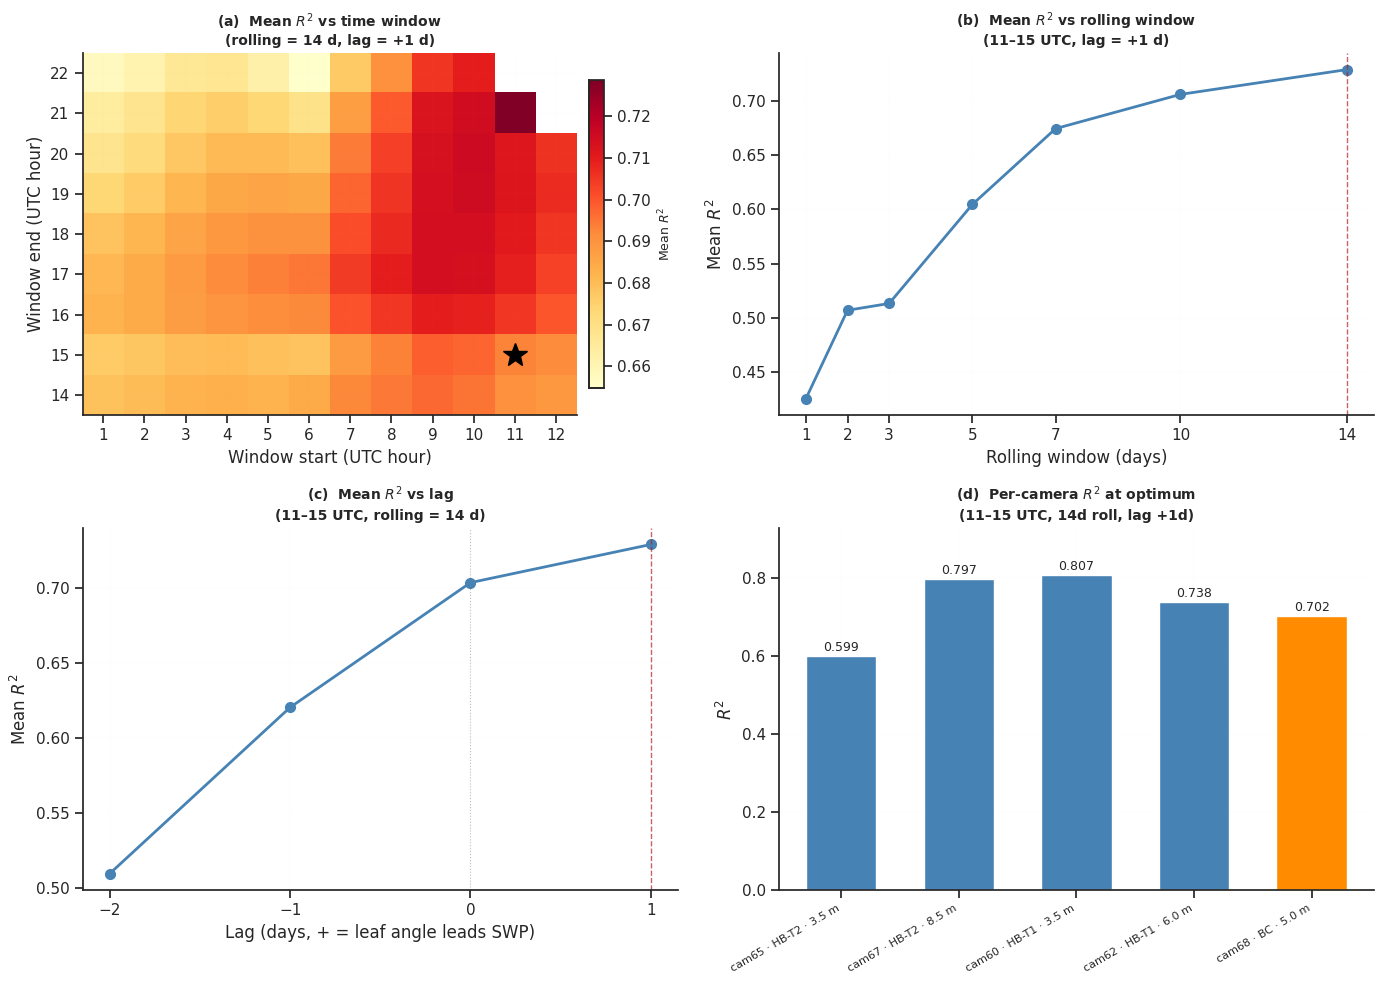

In [271]:
from itertools import product

# ── Settings ──────────────────────────────────────────────────────────────────
OPT_FIG_OUT = ROOT_DIR / "figures" / "optimal_window_swp_vs_leaf_angle.png"

# Cameras to optimise over (same 5 as correlation plot)
OPT_CAMS = [
    (65, "h10546"),
    (67, "h10546"),
    (60, "h10559"),
    (62, "h10559"),
    (68, "h11033"),
]
CAM_LABELS = {
    65: "cam65 · HB-T2 · 3.5 m",
    67: "cam67 · HB-T2 · 8.5 m",
    60: "cam60 · HB-T1 · 3.5 m",
    62: "cam62 · HB-T1 · 6.0 m",
    68: "cam68 · BC · 5.0 m",
}

# Search grid
START_HOURS = list(range(1, 13))          # 1 … 12
END_HOURS   = list(range(14, 23))         # 14 … 22
ROLL_DAYS   = [1, 2, 3, 5, 7, 10, 14]    # rolling-mean windows
LAG_DAYS    = list(range(-2, 2))          # -3 … +3  (positive = leaf angle leads SWP)

# ── Grid search ──────────────────────────────────────────────────────────────
print("Running grid search …")
records = []
for h0, h1, rd, lag in product(START_HOURS, END_HOURS, ROLL_DAYS, LAG_DAYS):
    if h1 - h0 < 4:                       # skip very narrow windows
        continue
    mask = (leaf_u_filtered.index.hour >= h0) & (leaf_u_filtered.index.hour < h1)
    la_d = leaf_u_filtered[mask].resample("1D").mean()
    la_r = la_d.rolling(rd, center=True).mean()

    # Apply lag: shift leaf angle by `lag` days
    # positive lag → leaf angle on day T compared with SWP on day T+lag
    la_r_shifted = la_r.shift(-lag)

    cam_r2 = {}
    for cam, tree in OPT_CAMS:
        col = f"leaf_angle_cam{cam}"
        if col not in la_r_shifted.columns:
            continue
        merged = pd.concat([la_r_shifted[col].rename("la"), swp_predawn.rename("swp")], axis=1).dropna()
        if len(merged) < 15:
            continue
        x, y = merged["la"].values, merged["swp"].values
        ss_tot = np.sum((y - y.mean()) ** 2)
        if ss_tot == 0:
            continue
        best = 0.0
        for deg in (1, 2):
            try:
                p = np.polyfit(x, y, deg)
                r2 = 1 - np.sum((y - np.polyval(p, x)) ** 2) / ss_tot
                best = max(best, r2)
            except Exception:
                pass
        cam_r2[cam] = best

    if len(cam_r2) == len(OPT_CAMS):
        records.append({
            "h0": h0, "h1": h1, "roll": rd, "lag": lag,
            "mean_r2": np.mean(list(cam_r2.values())),
            **{f"r2_cam{c}": cam_r2[c] for c in cam_r2},
        })

res = pd.DataFrame(records)
print(f"Tested {len(res)} parameter combinations")

# ── Find optimum ──────────────────────────────────────────────────────────────
best_row = res.loc[res["mean_r2"].idxmax()]
opt_h0   = int(best_row["h0"])
opt_h1   = int(best_row["h1"])
opt_roll = int(best_row["roll"])
opt_lag  = int(best_row["lag"])
lag_str  = f"{opt_lag:+d}" if opt_lag != 0 else "0"
print(f"\n★  Optimal:  window {opt_h0}–{opt_h1} UTC,  rolling {opt_roll} d,  "
      f"lag {lag_str} d,  mean R² = {best_row['mean_r2']:.4f}")
for cam, _ in OPT_CAMS:
    print(f"   cam{cam}  R² = {best_row[f'r2_cam{cam}']:.4f}")

# ── Prepare data for plots ────────────────────────────────────────────────────
# (A) Heatmap: mean R² vs (h0, h1) at best rolling & best lag
heat = res[(res["roll"] == opt_roll) & (res["lag"] == opt_lag)].pivot(
    index="h1", columns="h0", values="mean_r2")
heat = heat.sort_index(ascending=False)

# (B) Line: mean R² vs rolling at best time window & best lag
line_roll = res[(res["h0"] == opt_h0) & (res["h1"] == opt_h1) & (res["lag"] == opt_lag)].sort_values("roll")

# (C) Line: mean R² vs lag at best time window & best rolling
line_lag = res[(res["h0"] == opt_h0) & (res["h1"] == opt_h1) & (res["roll"] == opt_roll)].sort_values("lag")

# (D) Per-camera bar at optimum
cam_ids = [c for c, _ in OPT_CAMS]
cam_r2_opt = [best_row[f"r2_cam{c}"] for c in cam_ids]

# ── Figure (4 panels) ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Heatmap — time window
ax = axes[0, 0]
im = ax.imshow(heat.values, aspect="auto",
               extent=[heat.columns.min() - 0.5, heat.columns.max() + 0.5,
                       heat.index.min() - 0.5, heat.index.max() + 0.5],
               origin="lower", cmap="YlOrRd")
ax.plot(opt_h0, opt_h1, marker="*", color="black", ms=18, zorder=5)
ax.set_xlabel("Window start (UTC hour)")
ax.set_ylabel("Window end (UTC hour)")
ax.set_title(f"(a)  Mean $R^2$ vs time window\n(rolling = {opt_roll} d, lag = {lag_str} d)",
             fontsize=10, fontweight="bold")
ax.set_xticks(heat.columns)
ax.set_yticks(heat.index)
cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("Mean $R^2$", fontsize=9)

# (b) R² vs rolling window
ax = axes[0, 1]
ax.plot(line_roll["roll"], line_roll["mean_r2"], "o-", color="steelblue", lw=2, ms=7)
ax.axvline(opt_roll, color="firebrick", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Rolling window (days)")
ax.set_ylabel("Mean $R^2$")
ax.set_title(f"(b)  Mean $R^2$ vs rolling window\n({opt_h0}–{opt_h1} UTC, lag = {lag_str} d)",
             fontsize=10, fontweight="bold")
ax.set_xticks(ROLL_DAYS)

# (c) R² vs lag
ax = axes[1, 0]
ax.plot(line_lag["lag"], line_lag["mean_r2"], "o-", color="steelblue", lw=2, ms=7)
ax.axvline(opt_lag, color="firebrick", ls="--", lw=1, alpha=0.7)
ax.axvline(0, color="gray", ls=":", lw=0.8, alpha=0.5)
ax.set_xlabel("Lag (days, + = leaf angle leads SWP)")
ax.set_ylabel("Mean $R^2$")
ax.set_title(f"(c)  Mean $R^2$ vs lag\n({opt_h0}–{opt_h1} UTC, rolling = {opt_roll} d)",
             fontsize=10, fontweight="bold")
ax.set_xticks(LAG_DAYS)

# (d) Per-camera R² at optimum
ax = axes[1, 1]
colors_bar = ["steelblue"] * len(cam_ids)
for i, (cam, tree) in enumerate(OPT_CAMS):
    if tree == "h11033":
        colors_bar[i] = "darkorange"
bars = ax.bar([CAM_LABELS[c] for c in cam_ids], cam_r2_opt, color=colors_bar,
              edgecolor="white", width=0.6)
ax.set_ylabel("$R^2$")
ax.set_title(f"(d)  Per-camera $R^2$ at optimum\n({opt_h0}–{opt_h1} UTC, {opt_roll}d roll, lag {lag_str}d)",
             fontsize=10, fontweight="bold")
ax.set_ylim(0, max(cam_r2_opt) * 1.15)
for bar, v in zip(bars, cam_r2_opt):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

sns.despine(fig=fig, right=True, top=True)
plt.tight_layout()

if OPT_FIG_OUT:
    OPT_FIG_OUT.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(OPT_FIG_OUT, dpi=200, bbox_inches="tight")
    print(f"\nSaved → {OPT_FIG_OUT}")

plt.show()

Saved → /mnt/data/lk1167/projects/dehar-spac/figures/swp_vs_leaf_angle_2panel.png


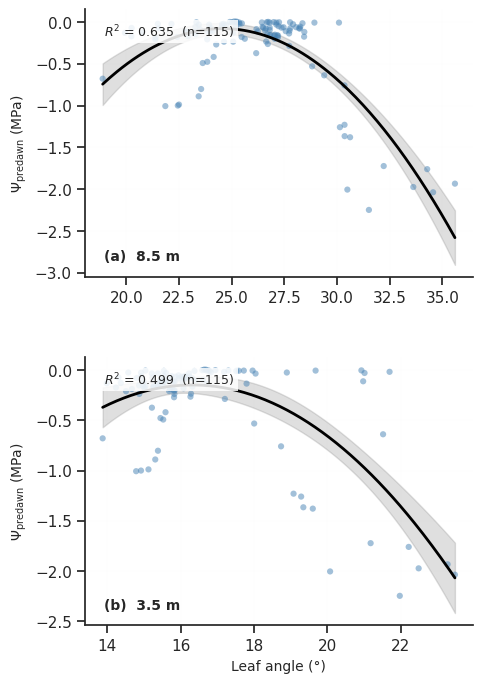

In [289]:
# ── Settings ──────────────────────────────────────────────────────────────────
SWP_LA_WINDOW  = (11, 15)
SWP_LA_ROLLING = 5
SWP_LA_CAMS    = [(67, 8.5), (65, 3.5)]   # (cam_id, height_m)
SWP_LA_FIG_OUT = ROOT_DIR / "figures" / "swp_vs_leaf_angle_2panel.png"

# ── Prepare leaf-angle: filtered → windowed → daily mean → rolling ────────────
_sh0, _sh1 = SWP_LA_WINDOW
_sla_filt = leaf_u_filtered
_sla_win  = _sla_filt[(_sla_filt.index.hour >= _sh0) & (_sla_filt.index.hour < _sh1)]
_sla_day  = _sla_win.resample("1D").mean()
_sla_roll = _sla_day.rolling(SWP_LA_ROLLING, center=True).mean()

# SWP predawn — already computed (no rolling applied)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(5, 8), gridspec_kw={"hspace": 0.30})

for i, (cam, ht) in enumerate(SWP_LA_CAMS):
    ax = axes[i]
    col = f"leaf_angle_cam{cam}"
    merged = pd.concat([swp_predawn.rename("swp"),
                        _sla_roll[col].rename("la")], axis=1).dropna()
    x = merged["la"].values
    y = merged["swp"].values

    # Scatter
    ax.scatter(x, y, s=20, alpha=0.5, color="steelblue", edgecolors="none", zorder=2)

    # Quadratic fit with confidence band
    p, cov = np.polyfit(x, y, 2, cov=True)
    xs = np.linspace(x.min(), x.max(), 200)
    yfit = np.polyval(p, xs)

    # Prediction SE from covariance matrix
    X_pred = np.column_stack([xs**2, xs, np.ones_like(xs)])
    se = np.sqrt(np.diag(X_pred @ cov @ X_pred.T))
    ci = 1.96 * se

    # R²
    ss_res = np.sum((y - np.polyval(p, x)) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    ax.fill_between(xs, yfit - ci, yfit + ci, color="grey", alpha=0.25, zorder=1)
    ax.plot(xs, yfit, color="black", lw=2, zorder=3)

    ax.text(0.05, 0.95, f"$R^2$ = {r2:.3f}  (n={len(x)})",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2))

    letter = chr(ord("a") + i)
    ax.text(0.05, 0.05, f"({letter})  {ht} m", transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="bottom")

    ax.set_ylabel(r"$\Psi_\mathrm{predawn}$ (MPa)", fontsize=10)
    if i == 1:
        ax.set_xlabel("Leaf angle (°)", fontsize=10)

sns.despine(fig=fig, right=True, top=True)
plt.tight_layout()

if SWP_LA_FIG_OUT:
    SWP_LA_FIG_OUT.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SWP_LA_FIG_OUT, dpi=200, bbox_inches="tight")
    print(f"Saved → {SWP_LA_FIG_OUT}")

plt.show()